<div style="background-color:#121212; padding:25px; border-radius:15px; box-shadow:0 0 15px rgba(255,255,255,0.1); font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">

  <h2 style="color:#ffffff; text-align:center; font-size:30px; letter-spacing:1px; margin-bottom:20px;">
    Netflix Data Cleaning
  </h2>
    

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# load the dataset into pandas Dataframe 
df = pd.read_csv('archive/netflix1.csv')

# Display first 5 rows 
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
# check for data shape 
df.shape

(8790, 10)

In [4]:
#list all columns names 
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [6]:
# Clean + parse the date_added column
date_source = df['date_added']
if pd.api.types.is_datetime64_any_dtype(date_source) or date_source.isna().all():
    # Recover original strings if date_added was previously coerced to all-NaT
    date_source = pd.read_csv('archive/netflix1.csv', usecols=['date_added'])['date_added']

date_source = (
    date_source
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .replace({'': pd.NA})
 )
df['date_added'] = pd.to_datetime(date_source, format='%m/%d/%Y', errors='coerce')

In [8]:
# check
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
if 'release_year' in df.columns:
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')

In [14]:
type_counts=df['type'].value_counts()
print(type_counts)

type
Movie      6126
Tv Show    2664
Name: count, dtype: Int64


In [16]:
df['country'] = df['country'].str.split(',')

In [17]:
# Quick quality check after cleaning
display(df.isna().sum().sort_values(ascending=False).head(15))
display(df.head())

show_id           0
type              0
title             0
director          0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
duration_value    0
duration_unit     0
dtype: int64

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,[United States],2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,[France],2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,seasons
2,s6,Tv Show,Midnight Mass,Mike Flanagan,[United States],2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,seasons
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,[Brazil],2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,[United States],2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [18]:
country_df=df.explode('country')

In [19]:
country_df['country']=country_df['country'].str.strip().str.title()

In [20]:
country_df['country'].unique()

<StringArray>
[       'United States',               'France',               'Brazil',
       'United Kingdom',                'India',              'Germany',
             'Pakistan',            'Not Given',                'China',
         'South Africa',                'Japan',              'Nigeria',
                'Spain',          'Philippines',            'Australia',
            'Argentina',               'Canada',            'Hong Kong',
                'Italy',          'New Zealand',                'Egypt',
             'Colombia',               'Mexico',              'Belgium',
          'Switzerland',               'Taiwan',             'Bulgaria',
               'Poland',          'South Korea',         'Saudi Arabia',
             'Thailand',            'Indonesia',               'Kuwait',
             'Malaysia',              'Vietnam',              'Lebanon',
              'Romania',                'Syria', 'United Arab Emirates',
               'Sweden',            '

In [21]:
country_df['country'].replace({"East Germany":"Germany","West Germany":"Germany"},inplace=True)

/tmp/ipykernel_10495/838059658.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  country_df['country'].replace({"East Germany":"Germany","West Germany":"Germany"},inplace=True)


0       United States
1              France
2       United States
3              Brazil
4       United States
            ...      
8785           Turkey
8786    United States
8787         Pakistan
8788         Pakistan
8789         Pakistan
Name: country, Length: 8790, dtype: str

In [22]:
country_df['country'].dropna(inplace=True)

In [29]:
country_df['country'].value_counts().head(1)

country
United States    3240
Name: count, dtype: int64

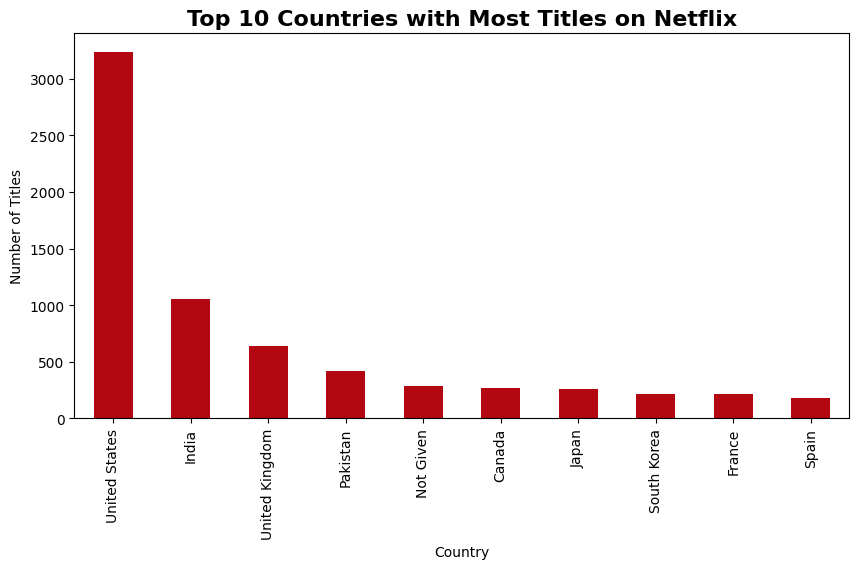

In [28]:
Country_counts=country_df['country'].value_counts().head(10)
Country_counts.plot(kind='bar', figsize=(10,5), color='#B20710')
plt.title("Top 10 Countries with Most Titles on Netflix",size=16,fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [30]:
df['release_year'].value_counts().head(1)

release_year
2018    1146
Name: count, dtype: Int64

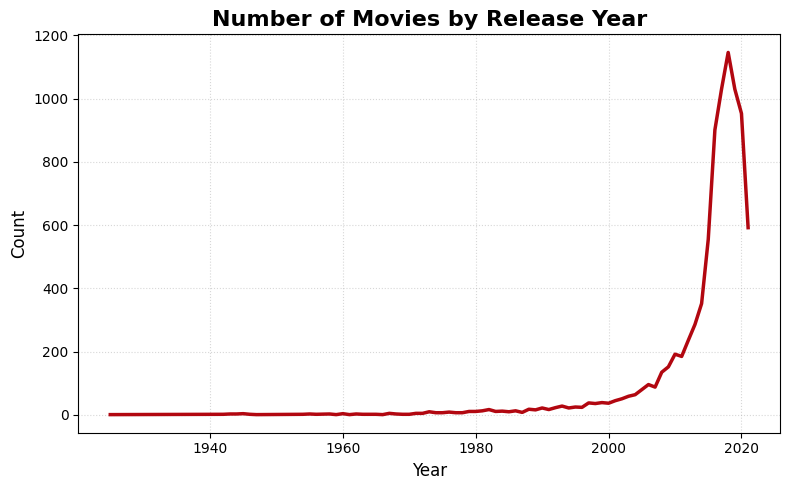

In [31]:
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.lineplot(x=release_counts.index, y=release_counts.values, color='#B20710', linewidth=2.5)

plt.title("Number of Movies by Release Year", fontsize=16, fontweight='bold', color='black')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
director_counts = df['director'].value_counts().head(10)
director_counts = director_counts[director_counts.index != 'Unknown']
top_directors = director_counts.head(10)
print(top_directors)

director
Not Given                 2588
Rajiv Chilaka               20
Raúl Campos, Jan Suter      18
Alastair Fothergill         18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: Int64


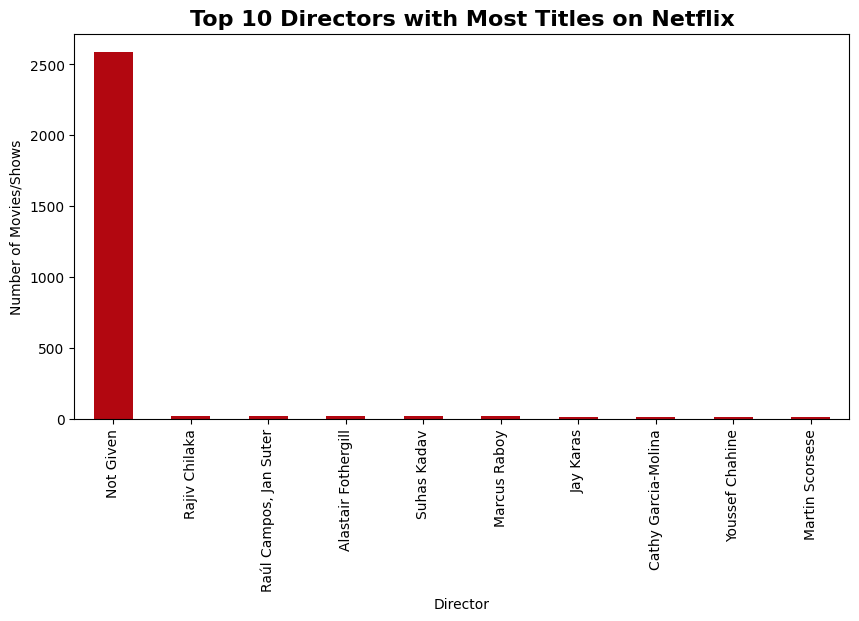

In [36]:
top_directors.plot(kind='bar', figsize=(10,5), color='#B20710')
plt.title("Top 10 Directors with Most Titles on Netflix",fontsize=16,fontweight='bold')
plt.xlabel("Director")
plt.ylabel("Number of Movies/Shows")
plt.show()